# Train gradient boosting machine
In this notebook I experimented with training small regression and ranking models, a bit in line with MS2Query one. What I tried to do is to rerank the top 100 highest scoring analogues, based on more detailed informtion. This information was the ms2deepscores tanimoto scores for the top 10 closest inchikeys. 

During this run I find out that actually the best approach is to just use the highest MS2DeepScore, but the magic touch is to do reliability prediction of the analogue in a different way. 

### NOTE The notebook is not cleaned. 
The results were not crucial to the story, so I didn't prioritise cleaning. So it is quite messy and I don't even think running from top to bottom will run. So it is mostly intended as a reference for code and results. The files are the same as in the other notebook, where we have the auto zenodo download. 

# Define benchmarking functions

In [77]:
import numpy as np
from matchms.similarity.vector_similarity_functions import jaccard_similarity_matrix

def calculate_tanimoto_score_between_pair(fingerprint_1: np.ndarray, fingerprint_2: np.ndarray) -> float:
    return jaccard_similarity_matrix(np.array([fingerprint_1]), np.array([fingerprint_2]))[0][0]
      
def get_average_tanimoto_after_filtering(
        query_spectrum_set, val_and_train_fingerprints, predicted_inchikeys
) -> float:
    """Calculates the average tanimoto of predictions made. Any predicted_inchikey that is None, is not considered and not used for the mean.
    """
    assert len(predicted_inchikeys) == len(query_spectrum_set)
    average_scores_per_inchikey = []
    # Calculate score per unique inchikey
    for inchikey in query_spectrum_set.spectrum_indices_per_inchikey.keys():
        matching_spectrum_indexes = query_spectrum_set.spectrum_indices_per_inchikey[inchikey]
        prediction_scores = []
        for index in matching_spectrum_indexes:
            predicted_inchikey = predicted_inchikeys[index]
            if predicted_inchikey is not None:
                predicted_fingerprint = val_and_train_fingerprints.get_fingerprints([predicted_inchikey])[0]
                actual_fingerprint = val_and_train_fingerprints.get_fingerprints([inchikey])[0]
                tanimoto_for_prediction = calculate_tanimoto_score_between_pair(
                    predicted_fingerprint, actual_fingerprint
                )
                prediction_scores.append(tanimoto_for_prediction)
        if len(prediction_scores) > 0:
            average_prediction = sum(prediction_scores) / len(prediction_scores)
            average_scores_per_inchikey.append(average_prediction)
    average_over_all_inchikeys = sum(average_scores_per_inchikey) / len(average_scores_per_inchikey)
    return average_over_all_inchikeys


def get_average_tanimoto_after_treshold(query_spectrum_set, val_and_train_fingerprints,
                                        predicted_inchikeys, predicted_scores, threshold):
    """Applies a threshold and calculates the average tanimoto. It returns both the fraction that passed the threshold and average tanimoto."""
    
    filtered_inchikeys = []
    nr_of_predictions = 0
    for index, score in enumerate(predicted_scores):
        if score > threshold:
            filtered_inchikeys.append(predicted_inchikeys[index])
            nr_of_predictions += 1
        else:
            filtered_inchikeys.append(None)
    prediction_fraction = nr_of_predictions/len(filtered_inchikeys)
    average_tanimoto = get_average_tanimoto_after_filtering(query_spectrum_set, val_and_train_fingerprints, filtered_inchikeys)
    return prediction_fraction, average_tanimoto

def get_average_tanimoto_for_list_of_thresholds(query_spectrum_set, val_and_train_fingerprints, 
                                                predicted_inchikeys, predicted_scores,
                                                list_of_thresholds = [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], ):
    assert len(predicted_scores) == len(predicted_inchikeys) == len(query_spectrum_set)
    prediction_fractions = []
    average_tanimotos = []
    for threshold in tqdm(list_of_thresholds, desc = "thresholds"):
        prediction_fraction, average_tanimoto = get_average_tanimoto_after_treshold(query_spectrum_set, val_and_train_fingerprints, predicted_inchikeys, predicted_scores, threshold)
        prediction_fractions.append(prediction_fraction)
        average_tanimotos.append(average_tanimoto)
    return prediction_fractions, average_tanimotos

In [78]:
import tqdm
from tqdm.auto import tqdm as auto_tqdm
tqdm.tqdm = auto_tqdm
from tqdm import tqdm

def predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys, prediction_method):
    """Predicts the best inchikey by using a specified method"""
    predicted_inchikeys = []
    predicted_scores = []
    for dict_with_ms2deepscores_for_top_inchikeys in tqdm(all_ms2deepscores_for_top_inchikeys):
        predicted_inchikey, predicted_score = prediction_method(dict_with_ms2deepscores_for_top_inchikeys)
        predicted_inchikeys.append(predicted_inchikey)
        predicted_scores.append(predicted_score)
    return predicted_inchikeys, predicted_scores
    
def predict_on_average_over_top_inchikeys(dict_with_ms2deepscores_for_top_inchikeys):
    highest_mean = 0
    best_inchikey = None
    for inchikey, close_tan_score in dict_with_ms2deepscores_for_top_inchikeys.items():
        mean = close_tan_score.get_mean()
        if mean > highest_mean:
            highest_mean = mean
            best_inchikey = inchikey
    return best_inchikey, highest_mean

def predict_on_higest_ms2deepscore(dict_with_close_tanimoto_scores):
    """Reusing the same results in the close_tanimoto_scores, but of course normally easier to go straight to the point""" 
    highest_score = 0
    best_inchikey = None
    for inchikey, close_tan_score in dict_with_close_tanimoto_scores.items():
        if inchikey in close_tan_score.ms2deepscores_per_inchikey:
            score = close_tan_score.ms2deepscores_per_inchikey[inchikey].max()
            if score > highest_score:
                highest_score = score
                best_inchikey = inchikey
    return best_inchikey, highest_score

def predict_on_max_over_top_inchikeys(dict_with_close_tanimoto_scores):
    highest_mean = 0
    best_inchikey = None
    for inchikey, close_tan_score in dict_with_close_tanimoto_scores.items():
        max_ms2deepscore_per_inchikey = close_tan_score.get_max_per_inchikey().values()
        mean = sum(max_ms2deepscore_per_inchikey) / len(max_ms2deepscore_per_inchikey)
        if mean > highest_mean:
            highest_mean = mean
            best_inchikey = inchikey
    return best_inchikey, highest_mean

def predict_on_mean_for_higest_ms2deepscore(dict_with_close_tanimoto_scores):
    """Reusing the same results in the close_tanimoto_scores, but of course normally easier to go straight to the point""" 
    highest_score = 0
    best_inchikey = None
    for inchikey, close_tan_score in dict_with_close_tanimoto_scores.items():
        if inchikey in close_tan_score.ms2deepscores_per_inchikey:
            score = close_tan_score.ms2deepscores_per_inchikey[inchikey].mean()
            if score > highest_score:
                highest_score = score
                best_inchikey = inchikey
    return best_inchikey, highest_score


# Load in data pos-pos
The data was generated in another notebook and loaded here.

In [1]:
import os
import pickle

pickled_intermediates_data_folder = "./pickled_intermediates_pos"

# Load the pickled files
with open(os.path.join(pickled_intermediates_data_folder, "val.pickle"), "rb") as handle:
    val_pos = pickle.load(handle)
with open(os.path.join(pickled_intermediates_data_folder, "train.pickle"), "rb") as handle:
    train_pos = pickle.load(handle)
# with open(os.path.join(pickled_intermediates_data_folder, "train_fingerprints.pickle"), "rb") as handle:
#     train_fingerprints_pos = pickle.load(handle)
# with open(os.path.join(pickled_intermediates_data_folder, "top_10_tanimoto.pickle"), "rb") as handle:
#     top_k_tanimoto_scores_pos = pickle.load(handle)


Your CPU supports instructions that this binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2
For maximum performance, you can install NMSLIB from sources 
pip install --no-binary :all: nmslib


In [2]:
from ms2query.benchmarking.reference_methods.MS2DeepScoresForTopInChikeys import MS2DeepScoresForTopKInChikeys
with open(os.path.join(pickled_intermediates_data_folder, "close_tanimoto_scores.pickle"), "rb") as handle:
    all_ms2deepscores_for_top_inchikeys_pos_pos = pickle.load(handle)

In [3]:
from ms2query.benchmarking.Fingerprints import Fingerprints
val_fingerprints = Fingerprints.from_spectrum_set(val_pos, "daylight", 4096)


Get most common inchi per inchikey: 
Adding fingerprints to Inchikeys: 3119it [00:12, 246.83it/s]


In [4]:
train_fingerprints = Fingerprints.from_spectrum_set(train_pos, "daylight", 4096)


Get most common inchi per inchikey: 
Adding fingerprints to Inchikeys: 55572it [03:10, 291.79it/s]


In [5]:
val_and_train_fingerprints_pos_pos = Fingerprints.combine_fingerprints(val_fingerprints, train_fingerprints)

In [80]:
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_pos_pos, predict_on_average_over_top_inchikeys)
prediction_fractions_average_over_top_inchikeys_pos_pos, average_tanimotos_average_over_top_inchikeys_pos_pos = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

In [184]:
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_pos_pos, predict_on_higest_ms2deepscore)
prediction_fractions_highest_ms2deepscore_pos_pos, average_tanimotos_highest_ms2deepscore_pos_pos = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/14 [00:00<?, ?it/s]

In [ ]:
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_pos_pos, predict_on_max_over_top_inchikeys)
prediction_fractions_max_over_top_inchikeys, average_tanimotos_max_over_top_inchikeys = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.96])

In [143]:
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_pos_pos, predict_on_mean_for_higest_ms2deepscore)
prediction_fractions_mean_for_higest_ms2deepscore, average_tanimotos_mean_for_higest_ms2deepscore = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/14 [00:00<?, ?it/s]

In [143]:
def predict_on_average_over_top_inchikeys_minimum_tanimoto(dict_with_ms2deepscores_for_top_inchikeys):
    highest_mean = 0
    best_inchikey = ""
    for inchikey, close_tan_score in dict_with_ms2deepscores_for_top_inchikeys.items():
        mean_ms2deepscores = []

        for top_k_inchikey, tanimoto_score in close_tan_score.top_k_inchikeys_and_tanimoto_scores.items():
            if tanimoto_score >0.3:
                mean_ms2deepscores.append(close_tan_score.ms2deepscores_per_inchikey[top_k_inchikey].mean())
        overall_mean = sum(mean_ms2deepscores)/ len(mean_ms2deepscores)
        if overall_mean > highest_mean:
            highest_mean = overall_mean
            best_inchikey = inchikey
    return best_inchikey, highest_mean
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_pos_pos, predict_on_average_over_top_inchikeys_minimum_tanimoto)
prediction_fractions_on_average_over_top_inchikeys_minimum_tanimoto_0_3, average_tanimotos_on_average_over_top_inchikeys_minimum_tanimoto_0_3 = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.96])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/10 [00:00<?, ?it/s]

In [138]:
def predict_on_average_over_top_5_tanimoto(dict_with_ms2deepscores_for_top_inchikeys):
    highest_mean = 0
    best_inchikey = ""
    for inchikey, close_tan_score in dict_with_ms2deepscores_for_top_inchikeys.items():
        mean_ms2deepscores = []
        for top_k_inchikey, tanimoto_score in list(dict(sorted(close_tan_score.top_k_inchikeys_and_tanimoto_scores.items(), key=lambda item: item[1], reverse=True)).items())[:3]:
            mean_ms2deepscores.append(close_tan_score.ms2deepscores_per_inchikey[top_k_inchikey].mean())
        overall_mean = sum(mean_ms2deepscores)/ len(mean_ms2deepscores)
        if overall_mean > highest_mean:
            highest_mean = overall_mean
            best_inchikey = inchikey
    return best_inchikey, highest_mean
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_pos_pos, predict_on_average_over_top_5_tanimoto)
prediction_fractions_on_average_over_top_3_tanimoto, average_tanimotos_on_average_over_top_3_tanimoto = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.96])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/10 [00:00<?, ?it/s]

In [125]:
def predict_on_difference_between_ms2ds_and_tanimoto(dict_with_ms2deepscores_for_top_inchikeys):
    highest_mean = 0
    best_inchikey = ""
    for inchikey, close_tan_score in dict_with_ms2deepscores_for_top_inchikeys.items():
        difference_between_tan_and_ms2deepscore = []

        for top_k_inchikey, tanimoto_score in close_tan_score.top_k_inchikeys_and_tanimoto_scores.items():
            mean_ms2deepscore = close_tan_score.ms2deepscores_per_inchikey[top_k_inchikey].mean()
            difference_between_tan_and_ms2deepscore.append(1 - abs(mean_ms2deepscore - tanimoto_score))
        overall_mean = sum(difference_between_tan_and_ms2deepscore)/ len(difference_between_tan_and_ms2deepscore)
        if overall_mean > highest_mean:
            highest_mean = overall_mean
            best_inchikey = inchikey
    return best_inchikey, highest_mean
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_pos_pos, predict_on_difference_between_ms2ds_and_tanimoto)
prediction_fractions_on_difference_between_ms2ds_and_tanimoto, average_tanimotos_on_difference_between_ms2ds_and_tanimoto = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.96])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/10 [00:00<?, ?it/s]

In [122]:
def predict_on_average_over_top_inchikeys_use_average_tanimoto(dict_with_ms2deepscores_for_top_inchikeys):
    highest_mean = 0
    best_inchikey = ""
    for inchikey, close_tan_score in dict_with_ms2deepscores_for_top_inchikeys.items():
        mean = close_tan_score.get_mean()
        if mean > highest_mean:
            highest_mean = mean
            tanimoto_scores = close_tan_score.top_k_inchikeys_and_tanimoto_scores.values()
            tanimoto = sum(tanimoto_scores)/ len(tanimoto_scores)
            best_inchikey = inchikey
    return best_inchikey, tanimoto
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_pos_pos, predict_on_average_over_top_inchikeys_use_average_tanimoto)
prediction_fractions_on_average_over_top_inchikeys_use_average_tanimoto, average_tanimotos_on_average_over_top_inchikeys_use_average_tanimoto = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.96])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/10 [00:00<?, ?it/s]

In [120]:
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_pos_pos, predict_on_average_over_top_inchikeys_minimum_tanimoto)
prediction_fractions_mean_for_higest_ms2deepscore_min_0_7, average_tanimotos_mean_for_higest_ms2deepscore_min_0_7 = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.96])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/10 [00:00<?, ?it/s]

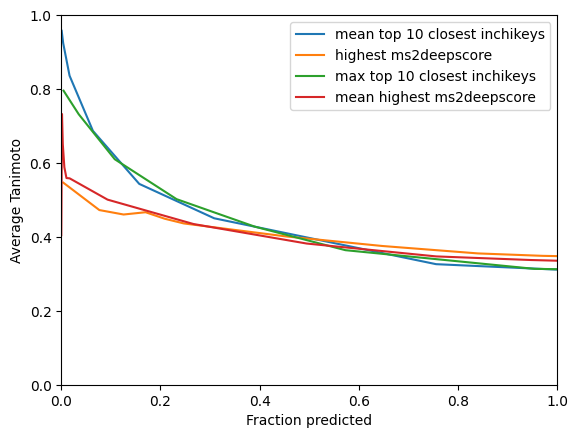

In [156]:
from matplotlib import pyplot as plt

plt.plot(prediction_fractions_average_over_top_inchikeys_pos_pos, average_tanimotos_average_over_top_inchikeys_pos_pos, label = "mean top 10 closest inchikeys")
plt.plot(prediction_fractions_highest_ms2deepscore_pos_pos, average_tanimotos_highest_ms2deepscore_pos_pos, label = "highest ms2deepscore")
plt.plot(prediction_fractions_max_over_top_inchikeys, average_tanimotos_max_over_top_inchikeys, label = "max top 10 closest inchikeys")
plt.plot(prediction_fractions_mean_for_higest_ms2deepscore, average_tanimotos_mean_for_higest_ms2deepscore, label = "mean highest ms2deepscore")
# plt.plot(prediction_fractions_on_average_over_top_inchikeys_minimum_tanimoto_0_4, average_tanimotos_on_average_over_top_inchikeys_minimum_tanimoto_0_4, label = "mean top 10 closest inchikeys above 0.4")
# plt.plot(prediction_fractions_on_average_over_top_inchikeys_minimum_tanimoto_0_3, average_tanimotos_on_average_over_top_inchikeys_minimum_tanimoto_0_3, label = "mean top 10 closest inchikeys above 0.3")

# plt.plot(prediction_fractions_on_average_over_top_inchikeys_use_average_tanimoto, average_tanimotos_on_average_over_top_inchikeys_use_average_tanimoto, label = "mean top 10, threshold on average tanimoto")
# plt.plot(prediction_fractions_on_difference_between_ms2ds_and_tanimoto, average_tanimotos_on_difference_between_ms2ds_and_tanimoto, label = "difference ms2deepscore and tanimoto")

# plt.plot(prediction_fractions_on_average_over_top_5_tanimoto, average_tanimotos_on_average_over_top_5_tanimoto, label = "mean_top_5_closest_inchikeys")
# plt.plot(prediction_fractions_on_average_over_top_3_tanimoto, average_tanimotos_on_average_over_top_3_tanimoto, label = "mean_top_3_closest_inchikeys")

plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

# Load in data posneg-posneg
After that the data is splitted on pos and neg.  

In [158]:
import os
import pickle

pickled_intermediates_data_folder = "./pickled_intermediates_pos_neg"

# Load the pickled files
with open(os.path.join(pickled_intermediates_data_folder, "val.pickle"), "rb") as handle:
    val_pos_neg = pickle.load(handle)


In [151]:
with open(os.path.join(pickled_intermediates_data_folder, "train.pickle"), "rb") as handle:
    train_pos_neg = pickle.load(handle)

In [148]:
with open(os.path.join(pickled_intermediates_data_folder, "close_tanimoto_scores.pickle"), "rb") as handle:
    all_ms2deepscores_for_top_inchikeys_pos_neg = pickle.load(handle)

In [152]:
from ms2query.benchmarking.Fingerprints import Fingerprints
val_fingerprints = Fingerprints.from_spectrum_set(val_pos_neg, "daylight", 4096)
train_fingerprints = Fingerprints.from_spectrum_set(train_pos_neg, "daylight", 4096)
val_and_train_fingerprints_pos_neg = Fingerprints.combine_fingerprints(val_fingerprints, train_fingerprints)

Get most common inchi per inchikey: 
Adding fingerprints to Inchikeys: 3119it [00:22, 140.34it/s]
Get most common inchi per inchikey: 
Adding fingerprints to Inchikeys: 60884it [04:51, 208.87it/s]


### Benchmark all cross ionmode

In [153]:
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_pos_neg, predict_on_average_over_top_inchikeys)
prediction_fractions_average_over_top_inchikeys_pos_neg, average_tanimotos_average_over_top_inchikeys_pos_neg = get_average_tanimoto_for_list_of_thresholds(val_pos_neg, val_and_train_fingerprints_pos_neg, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

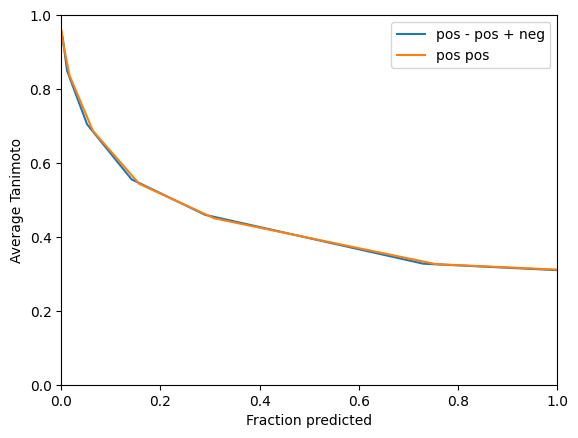

In [155]:
from matplotlib import pyplot as plt

plt.plot(prediction_fractions_average_over_top_inchikeys_pos_neg, average_tanimotos_average_over_top_inchikeys_pos_neg, label = "pos - pos + neg")
plt.plot(prediction_fractions_average_over_top_inchikeys_pos_pos, average_tanimotos_average_over_top_inchikeys_pos_pos, label = "pos pos")

plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

In [2]:
import os
import pickle

pickled_intermediates_data_folder = "./pickled_intermediates_neg"

# Load the pickled files
with open(os.path.join(pickled_intermediates_data_folder, "val.pickle"), "rb") as handle:
    val_neg = pickle.load(handle)
with open(os.path.join(pickled_intermediates_data_folder, "train.pickle"), "rb") as handle:
    train_neg = pickle.load(handle)

Your CPU supports instructions that this binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2
For maximum performance, you can install NMSLIB from sources 
pip install --no-binary :all: nmslib


In [161]:
with open(os.path.join(pickled_intermediates_data_folder, "close_tanimoto_scores.pickle"), "rb") as handle:
    all_ms2deepscores_for_top_inchikeys_neg_neg = pickle.load(handle)

In [165]:
from ms2query.benchmarking.Fingerprints import Fingerprints
val_fingerprints = Fingerprints.from_spectrum_set(val_neg, "daylight", 4096)
val_and_train_fingerprints_pos_neg = Fingerprints.combine_fingerprints(val_fingerprints, val_and_train_fingerprints_pos_neg)

Get most common inchi per inchikey: 
Adding fingerprints to Inchikeys: 1614it [00:06, 239.67it/s]


In [166]:
# predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_neg_neg, predict_on_average_over_top_inchikeys)
prediction_fractions_average_over_top_inchikeys_neg_neg, average_tanimotos_average_over_top_inchikeys_neg_neg = get_average_tanimoto_for_list_of_thresholds(val_neg, val_and_train_fingerprints_pos_neg, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

In [167]:
import os
import pickle

pickled_intermediates_data_folder = "./pickled_intermediates_neg_pos"

with open(os.path.join(pickled_intermediates_data_folder, "close_tanimoto_scores.pickle"), "rb") as handle:
    all_ms2deepscores_for_top_inchikeys_neg_to_pos_neg = pickle.load(handle)

In [168]:
predicted_inchikeys, predicted_scores = predict_best_inchikeys(all_ms2deepscores_for_top_inchikeys_neg_to_pos_neg, predict_on_average_over_top_inchikeys)
prediction_fractions_average_over_top_inchikeys_neg_to_pos_neg, average_tanimotos_average_over_top_inchikeys_neg_to_pos_neg = get_average_tanimoto_for_list_of_thresholds(val_neg, val_and_train_fingerprints_pos_neg, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

  0%|          | 0/15967 [00:00<?, ?it/s]

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

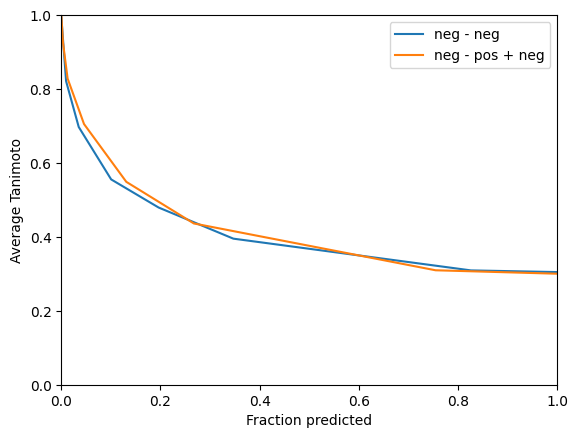

In [170]:
from matplotlib import pyplot as plt

plt.plot(prediction_fractions_average_over_top_inchikeys_neg_neg, average_tanimotos_average_over_top_inchikeys_neg_neg, label = "neg - neg")
plt.plot(prediction_fractions_average_over_top_inchikeys_neg_to_pos_neg, average_tanimotos_average_over_top_inchikeys_neg_to_pos_neg, label = "neg - pos + neg")

plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

# Train ranking model

In [ ]:
from ms2query.benchmarking.reference_methods.predict_best_possible_match import predict_best_possible_match

inchikeys_of_best_match, highest_scores = predict_best_possible_match(train_pos, val_pos, val_and_train_fingerprints_pos_pos)

In [8]:
import random

n_train_inchikeys = int(0.8 * len(val_pos.spectrum_indices_per_inchikey))
train_query_inchikeys = random.sample(list(val_pos.spectrum_indices_per_inchikey.keys()), n_train_inchikeys)
val_query_inchikeys = [inchikey for inchikey in val_pos.spectrum_indices_per_inchikey.keys() if inchikey not in set(train_query_inchikeys)]


In [9]:
import numpy as np
from matchms.similarity.vector_similarity_functions import jaccard_similarity_matrix
import lightgbm as lgb
def compute_similarity_feature_vector(tanimoto_scores, ms2deepscores):
    """
    Returns a flat feature list containing:
    - original tanimoto scores
    - original ms2deepscores
    - aggregated statistics
    """

    tanimoto_scores = np.array(tanimoto_scores)
    ms2deepscores = np.array(ms2deepscores)

    features = []

    # ---- Original raw scores ----
    features.extend(tanimoto_scores.tolist())
    features.extend(ms2deepscores.tolist())

    # ---- Basic statistics ----
    features.append(np.mean(tanimoto_scores))
    features.append(np.max(tanimoto_scores))
    features.append(np.min(tanimoto_scores))
    features.append(np.std(tanimoto_scores))
    features.append(np.median(tanimoto_scores))

    features.append(np.mean(ms2deepscores))
    features.append(np.max(ms2deepscores))
    features.append(np.min(ms2deepscores))
    features.append(np.std(ms2deepscores))
    features.append(np.median(ms2deepscores))

    corr = np.corrcoef(tanimoto_scores, ms2deepscores)[0, 1]

    if np.isnan(corr):
        corr = 0.0

    features.append(corr)

    return features

def get_pairwise_score_matrix(ms2deepscores_for_top_k_inchikeys):
    tanimoto_scores = []
    mean_ms2ds = []
    mean_score_per_inchikey = ms2deepscores_for_top_k_inchikeys.get_mean_per_inchikey()
    for inchikey, tanimoto in sorted(ms2deepscores_for_top_k_inchikeys.top_k_inchikeys_and_tanimoto_scores.items(), key=lambda x: x[1]):
        tanimoto_scores.append(tanimoto)
        mean_ms2ds.append(float(mean_score_per_inchikey[inchikey]))
    tanimoto_scores, mean_ms2ds
    return compute_similarity_feature_vector(tanimoto_scores, mean_ms2ds)

def get_y_for_query_spectrum(dictionary_with_scores, best_possible_inchikey):
    
    possible_inchikeys = list(dictionary_with_scores.keys())
    
    library_fingerprints = val_and_train_fingerprints_pos_pos.get_fingerprints(possible_inchikeys)
    query_fingerprints = val_and_train_fingerprints_pos_pos.get_fingerprints([best_possible_inchikey])

    tanimoto_scores = jaccard_similarity_matrix(library_fingerprints, query_fingerprints)
    y_for_query_spectrum = []

    for tanimoto in tanimoto_scores:
        if tanimoto >=0.9:
            y_for_query_spectrum.append(2)
        elif tanimoto >=0.8:
            y_for_query_spectrum.append(1)
        # elif tanimoto >=0.6:
        #     y_for_query_spectrum.append(1)
        # elif tanimoto >=0.5:
        #     y_for_query_spectrum.append(1)
        else:
            y_for_query_spectrum.append(0)
    return y_for_query_spectrum, tanimoto_scores

def get_x_and_y(inchikeys):
    y_ranking = []
    y_tanimoto = []
    X = []
    for inchikey in tqdm(inchikeys):
        matching_spectrum_indexes = val_pos.spectrum_indices_per_inchikey[inchikey]
        for spectrum_index in matching_spectrum_indexes:
            dictionary_with_scores = all_ms2deepscores_for_top_inchikeys_pos_pos[spectrum_index]
            y_ranking_for_query_spectrum, y_tanimoto_for_query_spectrum = get_y_for_query_spectrum(dictionary_with_scores, inchikey)
            y_ranking.extend(y_ranking_for_query_spectrum)
            y_tanimoto.extend(y_tanimoto_for_query_spectrum)
            for scores in dictionary_with_scores.values():
                X.append(get_pairwise_score_matrix(scores))
    return np.array(X), np.array(y_ranking), np.array(y_tanimoto)

In [ ]:
X_complete_val = []
for dictionary_with_scores in tqdm(all_ms2deepscores_for_top_inchikeys_pos_pos):
    for scores in dictionary_with_scores.values():
        X_complete_val.append(get_pairwise_score_matrix(scores))
X_complete_val = np.array(X_complete_val)


  0%|          | 0/36473 [00:00<?, ?it/s]

/lustre/BIF/nobackup/jonge094/bin/miniconda3/envs/ms2query_2/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/lustre/BIF/nobackup/jonge094/bin/miniconda3/envs/ms2query_2/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
X, Y, y_tanimoto_scores = get_x_and_y(train_query_inchikeys)
X_val, Y_val, y_val_tanimoto_scores = get_x_and_y(val_query_inchikeys)

### Subset features to use

In [42]:
feature_indexes = [
    # 0,1,2,3,4,5,6,7,8,9,
    10,11,12,13,14,15,16,17,18,19,
    20,
    21,
    22,23,24,
    # 25,
    # 26,
    # 27,28, 29, 
    30 ,
]
selected_feature_names = [feature_names[i] for i in feature_indexes]
print(selected_feature_names)

['ms2deepscore_1', 'ms2deepscore_2', 'ms2deepscore_3', 'ms2deepscore_4', 'ms2deepscore_5', 'ms2deepscore_6', 'ms2deepscore_7', 'ms2deepscore_8', 'ms2deepscore_9', 'ms2deepscore_10', 'mean_tanimoto', 'max_tanimoto', 'min_tanimoto', 'standard_dev_tanimoto', 'median_tanimoto', 'Correlation tan and ms2deepscores']


In [61]:
import matplotlib.pyplot as plt

FEATURE_NAMES = ["tanimoto_1", "tanimoto_2", "tanimoto_3", "tanimoto_4", "tanimoto_5", "tanimoto_6", "tanimoto_7", "tanimoto_8", "tanimoto_9","tanimoto_10",
                 "ms2deepscore_1", "ms2deepscore_2", "ms2deepscore_3", "ms2deepscore_4", "ms2deepscore_5", "ms2deepscore_6", "ms2deepscore_7", "ms2deepscore_8", "ms2deepscore_9", "ms2deepscore_10", 
                "mean_tanimoto", "max_tanimoto", "min_tanimoto", "standard_dev_tanimoto", "median_tanimoto", "mean_ms2deepscores", "max_ms2deepscore", "min_ms2deepscore", "standard_dev ms2deepscore", "median_ms2deepscores", "Correlation tan and ms2deepscores"]

def print_importances(model, selected_feature_names):
    # Gain-based importance (best for ranking)
    importance = model.feature_importance(importance_type='gain')
    # Sort descending
    sorted_idx = np.argsort(importance)[::-1]
    for i in sorted_idx:
        print(f"{selected_feature_names[i]}: {importance[i]:.4f}")

def plot_importance(model, feature_indexes, model_name):
    selected_feature_names = [FEATURE_NAMES[i] for i in feature_indexes]

    # Gain-based importance (best for ranking)
    importance = model.feature_importance(importance_type='gain')
    # Sort descending
    sorted_idx = np.argsort(importance)[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(
        np.array(selected_feature_names)[sorted_idx],
        importance[sorted_idx]
    )
    plt.gca().invert_yaxis()
    plt.title(model_name)
    plt.xlabel("Gain Importance")
    plt.tight_layout()
    plt.show()
    
def train_regression_model(feature_indexes):
    train_data = lgb.Dataset(X[:, feature_indexes], label=y_tanimoto_scores)
    val_data = lgb.Dataset(X_val[:, feature_indexes], label=y_val_tanimoto_scores)

    params = {
        "objective": "regression",      # or "l2"
        "metric": "rmse",               # or "l2", "mae"
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_data_in_leaf": 20,
        "verbosity": -1
    }
    
    regression_model = lgb.train(
        params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=500,
        callbacks=[lgb.early_stopping(50)]
    )
    return regression_model

def train_ranking_model(feature_indexes):
    group_train = [100] * (len(X)//100)
    group_val = [100] * (len(X_val)//100)
    train_data = lgb.Dataset(X[:, feature_indexes], label=Y, group=group_train)
    val_data = lgb.Dataset(X_val[:, feature_indexes], label=Y_val, group=group_val)
    
    params = {
        "objective": "lambdarank",
        "metric": "ndcg",
        "ndcg_eval_at": [1],
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_data_in_leaf": 20,
        "verbosity": -1
    }
    
    model = lgb.train(
        params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=500,
        callbacks=[lgb.early_stopping(50)]
    )
    return model

In [56]:
def create_feature_set(individual_tanimoto, individual_ms2deepscore, statistics_tanimoto, statistics_ms2deepscore, correlation):
    feature_indexes = []
    model_name = ""
    if individual_tanimoto:
        feature_indexes.extend([0,1,2,3,4,5,6,7,8,9,])
        model_name += "tanimoto scores, "
    if individual_ms2deepscore:
        feature_indexes.extend([10,11,12,13,14,15,16,17,18,19])
        model_name += "ms2deepscore scores, "
    if statistics_tanimoto:
        feature_indexes.extend([20,21,22,23,24])
        model_name += "tanimoto statistics, "
    if statistics_ms2deepscore:
        feature_indexes.extend([25,26,27,28,29,])
        model_name += "ms2deepscore statistics, "
    if correlation:
        feature_indexes.append(30)
        model_name += "correlation"
    return feature_indexes, model_name

# Train regression models

In [64]:
model_results_dict = {}

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 0.119197


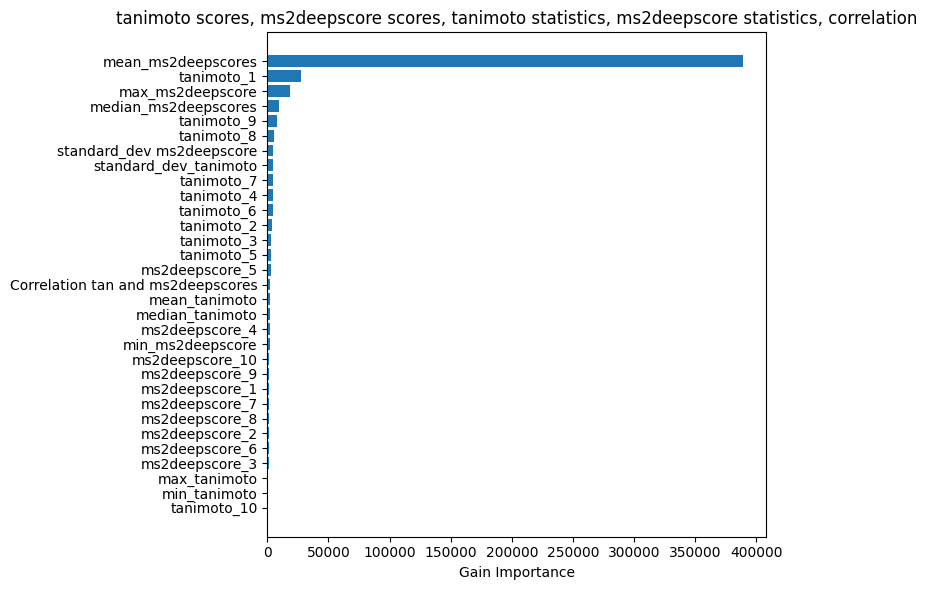

0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [65]:
feature_indexes, model_name = create_feature_set(True, True, True, True, True)
model = train_regression_model(feature_indexes)
plot_importance(model, feature_indexes, model_name)
fractions, tanimoto_scores = get_prediction_fractions_and_average_tanimoto(feature_indexes, model)
model_results_dict["regression " + model_name] = fractions, tanimoto_scores

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 0.119958


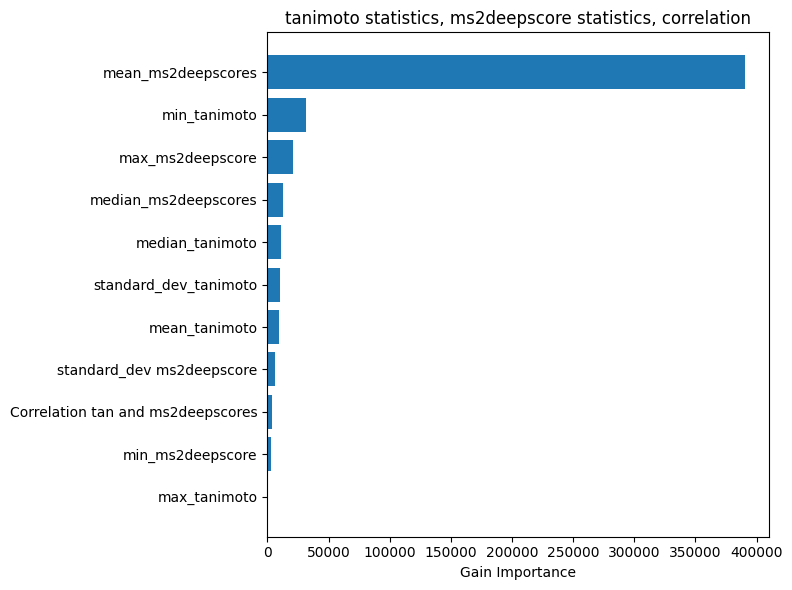

0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [66]:
feature_indexes, model_name = create_feature_set(False, False, True, True, True)
model = train_regression_model(feature_indexes)
plot_importance(model, feature_indexes, model_name)
fractions, tanimoto_scores = get_prediction_fractions_and_average_tanimoto(feature_indexes, model)
model_results_dict["regression " + model_name] = fractions, tanimoto_scores

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 0.119749


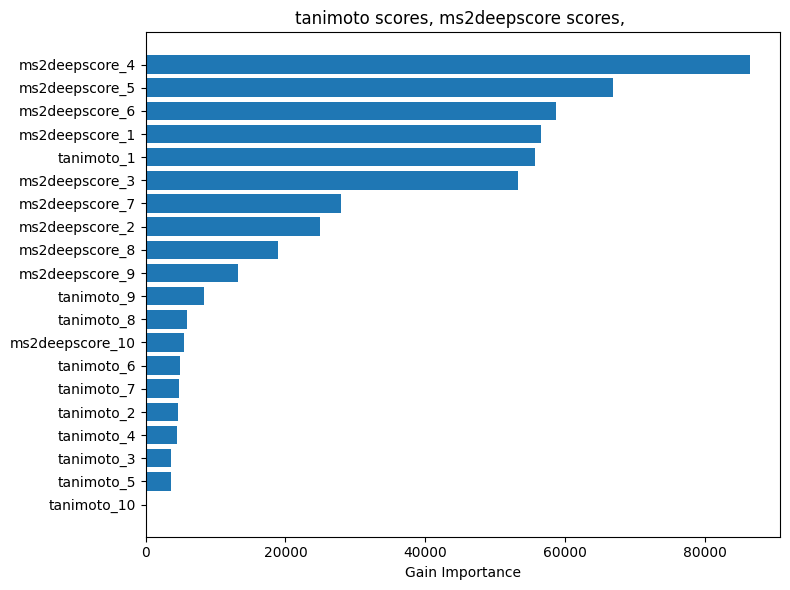

0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [67]:
feature_indexes, model_name = create_feature_set(True, True, False, False, False)
model = train_regression_model(feature_indexes)
plot_importance(model, feature_indexes, model_name)
fractions, tanimoto_scores = get_prediction_fractions_and_average_tanimoto(feature_indexes, model)
model_results_dict["regression " + model_name] = fractions, tanimoto_scores

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 0.120251


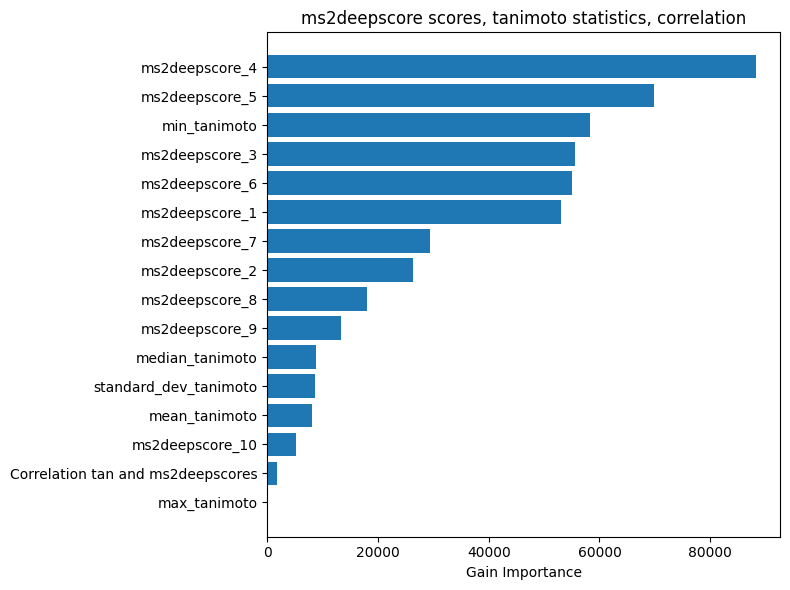

0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [68]:
feature_indexes, model_name = create_feature_set(False, True, True, False, True)
model = train_regression_model(feature_indexes)
plot_importance(model, feature_indexes, model_name)
fractions, tanimoto_scores = get_prediction_fractions_and_average_tanimoto(feature_indexes, model)
model_results_dict["regression " + model_name] = fractions, tanimoto_scores

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 0.119193


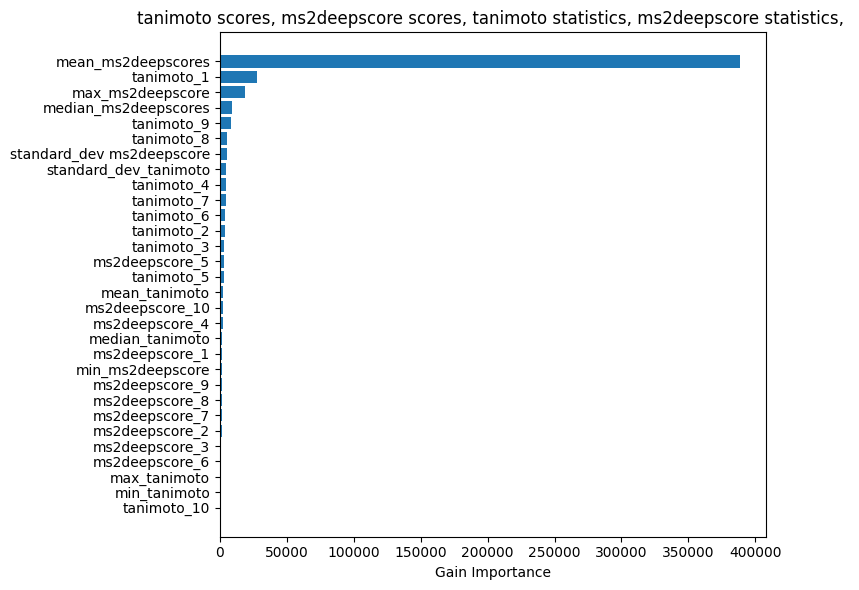

0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [89]:
feature_indexes, model_name = create_feature_set(True, True, True, True, False)
model = train_regression_model(feature_indexes)
plot_importance(model, feature_indexes, model_name)
fractions, tanimoto_scores = get_prediction_fractions_and_average_tanimoto(feature_indexes, model)
model_results_dict["regression " + model_name] = fractions, tanimoto_scores

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[102]	valid_0's ndcg@1: 0.730568


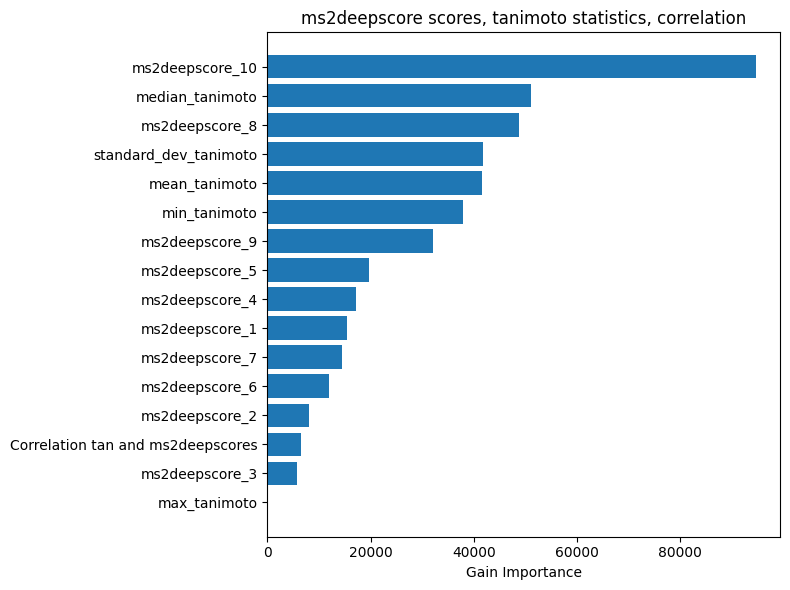

0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [69]:
feature_indexes, model_name = create_feature_set(False, True, True, False, True)
model = train_ranking_model(feature_indexes)
plot_importance(model, feature_indexes, model_name)
fractions, tanimoto_scores = get_prediction_fractions_and_average_tanimoto(feature_indexes, model)
model_results_dict["ranking " + model_name] = fractions, tanimoto_scores

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[31]	valid_0's ndcg@1: 0.730086


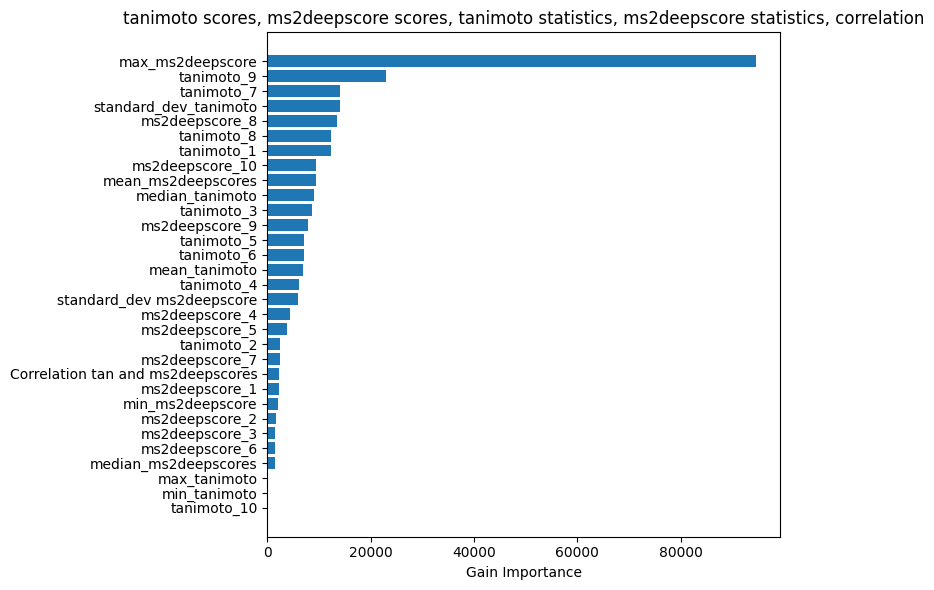

0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [70]:
feature_indexes, model_name = create_feature_set(True, True, True, True, True)
model = train_ranking_model(feature_indexes)
plot_importance(model, feature_indexes, model_name)
fractions, tanimoto_scores = get_prediction_fractions_and_average_tanimoto(feature_indexes, model)
model_results_dict["ranking " + model_name] = fractions, tanimoto_scores

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[83]	valid_0's ndcg@1: 0.73544


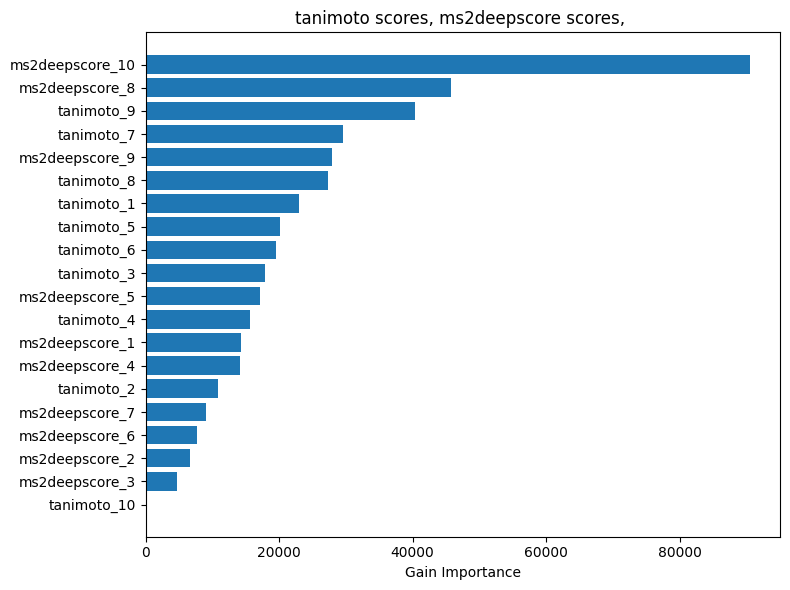

0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [71]:
feature_indexes, model_name = create_feature_set(True, True, False, False, False)
model = train_ranking_model(feature_indexes)
plot_importance(model, feature_indexes, model_name)
fractions, tanimoto_scores = get_prediction_fractions_and_average_tanimoto(feature_indexes, model)
model_results_dict["ranking " + model_name] = fractions, tanimoto_scores

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[85]	valid_0's ndcg@1: 0.730963


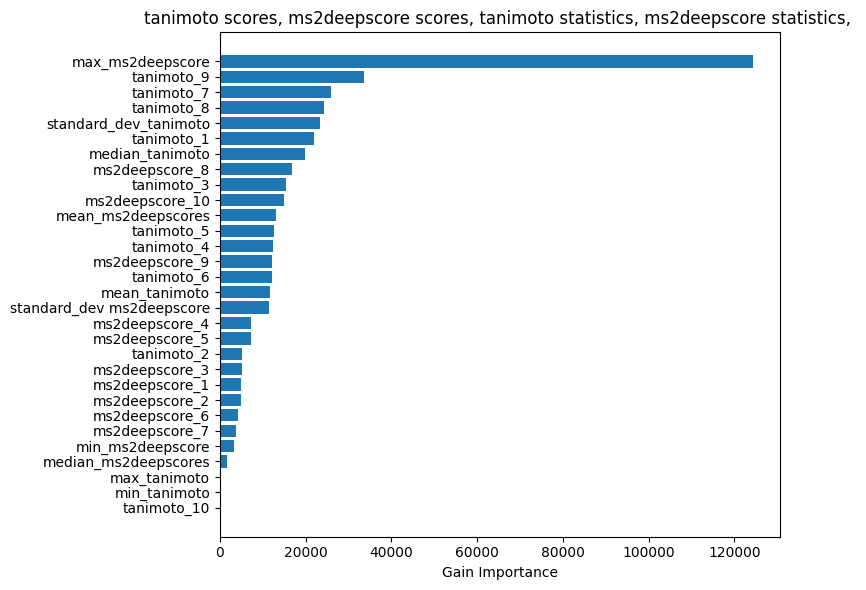

0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [87]:
feature_indexes, model_name = create_feature_set(True, True, True, True, False)
model = train_ranking_model(feature_indexes)
plot_importance(model, feature_indexes, model_name)
fractions, tanimoto_scores = get_prediction_fractions_and_average_tanimoto(feature_indexes, model)
model_results_dict["ranking " + model_name] = fractions, tanimoto_scores

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[144]	valid_0's ndcg@1: 0.733026


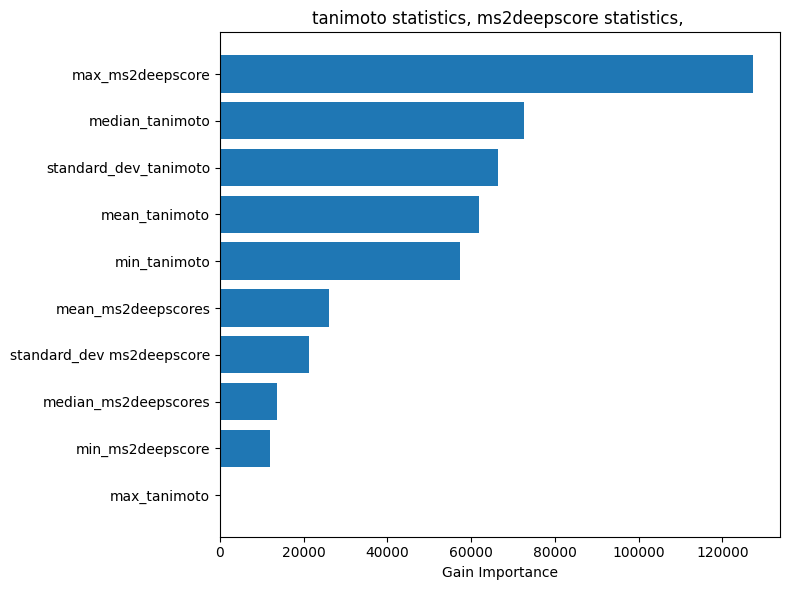

0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [84]:
feature_indexes, model_name = create_feature_set(False, False, True, True, False)
model = train_ranking_model(feature_indexes)
plot_importance(model, feature_indexes, model_name)
fractions, tanimoto_scores = get_prediction_fractions_and_average_tanimoto(feature_indexes, model)
model_results_dict["ranking " + model_name] = fractions, tanimoto_scores

# benchmark validation set

In [58]:

def get_predictions_and_scores(x, model, all_ms2deepscores_for_top_inchikeys):
    all_predicted_scores = model.predict(x)
    all_predicted_scores = all_predicted_scores.reshape(-1, 100)
    
    predicted_inchikeys = []
    scores = []
    for query_index, predicted_scores in tqdm(enumerate(all_predicted_scores)):
        highest_rank = np.argmax(predicted_scores)
        all_possible_inchikeys = list(all_ms2deepscores_for_top_inchikeys[query_index].keys())
        best_inchikey = all_possible_inchikeys[highest_rank]
        top_score = predicted_scores[highest_rank]
        predicted_inchikeys.append(best_inchikey)
        scores.append(top_score)
    return predicted_inchikeys, scores

def get_prediction_fractions_and_average_tanimoto(feature_indexes, model):
    predicted_inchikeys, scores = get_predictions_and_scores(X_complete_val[:, feature_indexes], model, all_ms2deepscores_for_top_inchikeys_pos_pos)
    prediction_fractions, average_tanimotos = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, scores, np.linspace(min(scores)+ 0.1, max(scores) - 0.1, 30))
    return prediction_fractions, average_tanimotos

In [81]:
model_results_dict.keys()

dict_keys(['regression tanimoto scores, ms2deepscore scores, tanimoto statistics, ms2deepscore statistics, correlation', 'regression tanimoto statistics, ms2deepscore statistics, correlation', 'regression tanimoto scores, ms2deepscore scores, ', 'regression ms2deepscore scores, tanimoto statistics, correlation', 'ranking ms2deepscore scores, tanimoto statistics, correlation', 'ranking tanimoto scores, ms2deepscore scores, tanimoto statistics, ms2deepscore statistics, correlation', 'ranking tanimoto scores, ms2deepscore scores, '])

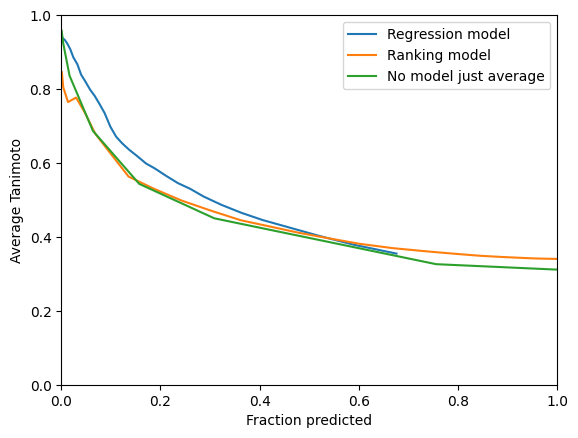

In [90]:
prediction_fraction, average_tanimotos = model_results_dict['regression tanimoto scores, ms2deepscore scores, tanimoto statistics, ms2deepscore statistics, ']
plt.plot(prediction_fraction, average_tanimotos, label = "Regression model")
prediction_fraction, average_tanimotos = model_results_dict['ranking tanimoto scores, ms2deepscore scores, tanimoto statistics, ms2deepscore statistics, ']
plt.plot(prediction_fraction, average_tanimotos, label = "Ranking model")
plt.plot(prediction_fractions_average_over_top_inchikeys_pos_pos, average_tanimotos_average_over_top_inchikeys_pos_pos, label = "No model just average")

plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

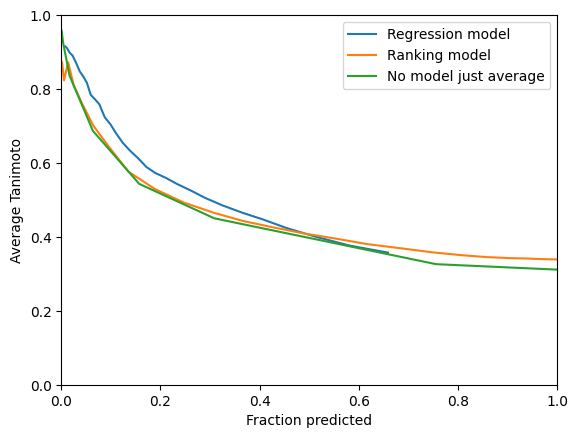

In [83]:
prediction_fraction, average_tanimotos = model_results_dict['regression tanimoto scores, ms2deepscore scores, tanimoto statistics, ms2deepscore statistics, ']
plt.plot(prediction_fraction, average_tanimotos, label = "Regression model")
prediction_fraction, average_tanimotos = model_results_dict['ranking tanimoto scores, ms2deepscore scores, tanimoto statistics, ms2deepscore statistics, ']
plt.plot(prediction_fraction, average_tanimotos, label = "Ranking model")
plt.plot(prediction_fractions_average_over_top_inchikeys_pos_pos, average_tanimotos_average_over_top_inchikeys_pos_pos, label = "No model just average")

plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

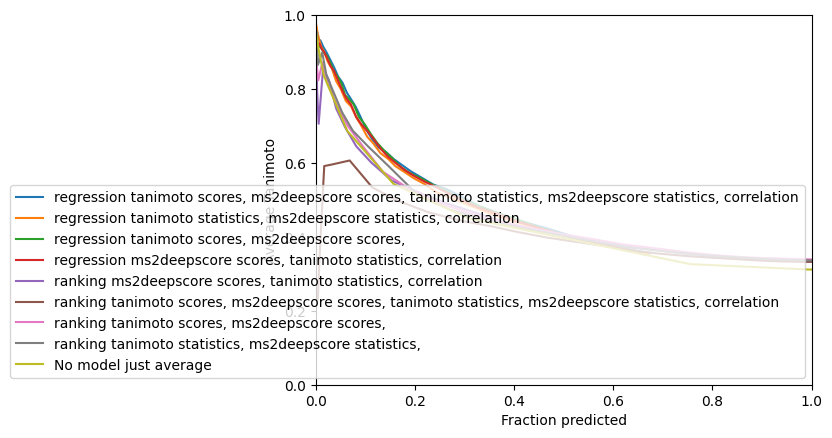

In [86]:
from matplotlib import pyplot as plt

for model_name, result in model_results_dict.items():
    prediction_fraction, average_tanimotos = result
    plt.plot(prediction_fraction, average_tanimotos, label = model_name)
# plt.plot(prediction_fractions, average_tanimotos, label = "reranking model 0.9, 0.8, 0.7, 0.5")
# plt.plot(prediction_fractions_08_09, average_tanimotos_08_09, label = "reranking model (no statistics)")
# # plt.plot(prediction_fractions_09, average_tanimotos_09, label = "reranking model 0.9")
# # plt.plot(prediction_fractions_09_08_06, average_tanimotos_09_08_06, label = "reranking model 0.9, 0.8, 0.6")
# plt.plot(prediction_fractions_with_statistics, average_tanimotos_with_statistics, label = "reranking model with statistics")
plt.plot(prediction_fractions_average_over_top_inchikeys_pos_pos, average_tanimotos_average_over_top_inchikeys_pos_pos, label = "No model just average")
# plt.plot(prediction_fractions_1, average_tanimotos_1, label = "ranking_model")
# plt.plot(prediction_fractions_regression, average_tanimotos_regression, label = "regression model")

plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

In [199]:
def predict_with_ranking_model(dict_with_scores_for_top_k, model):
    combined_pairwise_score_matrix = []
    for inchikey, scores_for_top_k in dict_with_scores_for_top_k.items():
        pairwise_score_matrix = get_pairwise_score_matrix(scores_for_top_k)
        combined_pairwise_score_matrix.append(pairwise_score_matrix)
    predicted_scores = model.predict(combined_pairwise_score_matrix)
    ranking_indices = np.argsort(predicted_scores)[::-1]  # descending order
    all_possible_inchikeys = list(dict_with_scores_for_top_k.keys())
    ranked_candidates = [all_possible_inchikeys[i] for i in ranking_indices]
    top_score = predicted_scores[ranking_indices[0]]

    return ranked_candidates[0], top_score
predicted_inchikeys = []
scores = []
for dict_with_scores_for_top_k in tqdm(all_ms2deepscores_for_top_inchikeys_pos_pos):
    highest_inchikey, top_score = predict_with_ranking_model(dict_with_scores_for_top_k, model)
    predicted_inchikeys.append(highest_inchikey)
    scores.append(top_score)

In [305]:
max(scores)

np.float64(1.018477663086824)

In [25]:
prediction_fractions_with_statistics, average_tanimotos_with_statistics = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, scores, np.linspace(min(scores)+ 0.01, max(scores) - 0.01, 30))

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
prediction_fractions, average_tanimotos = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, scores, np.linspace(min(scores)+ 0.1, max(scores) - 0.1, 10))

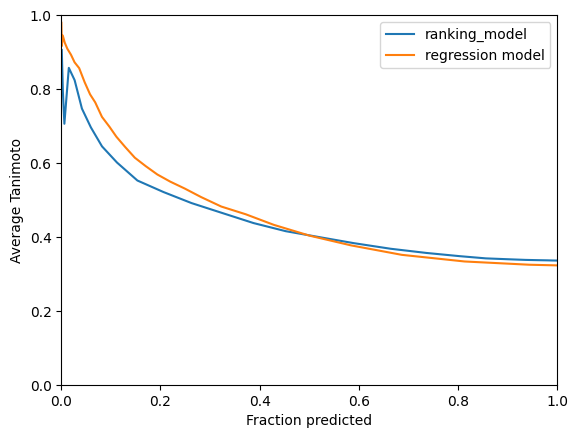

In [28]:
from matplotlib import pyplot as plt

# plt.plot(prediction_fractions, average_tanimotos, label = "reranking model 0.9, 0.8, 0.7, 0.5")
# plt.plot(prediction_fractions_08_09, average_tanimotos_08_09, label = "reranking model (no statistics)")
# # plt.plot(prediction_fractions_09, average_tanimotos_09, label = "reranking model 0.9")
# # plt.plot(prediction_fractions_09_08_06, average_tanimotos_09_08_06, label = "reranking model 0.9, 0.8, 0.6")
# plt.plot(prediction_fractions_with_statistics, average_tanimotos_with_statistics, label = "reranking model with statistics")
# plt.plot(prediction_fractions_average_over_top_inchikeys_pos_pos, average_tanimotos_average_over_top_inchikeys_pos_pos, label = "No model just average")
plt.plot(prediction_fractions_1, average_tanimotos_1, label = "ranking_model")
plt.plot(prediction_fractions_regression, average_tanimotos_regression, label = "regression model")

plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

# Test prediction on distribution of ms2deepscores (within inchikey)


In [135]:
def get_ms2deepscore_distribution_features(all_ms2deepscores_for_top_inchikeys):
    features_per_query = []
    for query_results in tqdm(all_ms2deepscores_for_top_inchikeys):
        for potential_inchikey, scores_per_inchikey in query_results.items():
            if potential_inchikey in scores_per_inchikey.ms2deepscores_per_inchikey:
                ms2deepscores = scores_per_inchikey.ms2deepscores_per_inchikey[potential_inchikey]
            else:
                highest_inchikey = max(scores_per_inchikey.top_k_inchikeys_and_tanimoto_scores, key=scores_per_inchikey.top_k_inchikeys_and_tanimoto_scores.get)
                ms2deepscores = scores_per_inchikey.ms2deepscores_per_inchikey[highest_inchikey]
            features_per_query.append((ms2deepscores.mean(), ms2deepscores.std(), ms2deepscores.max(), ms2deepscores.min(), len(ms2deepscores)))                                           
    return features_per_query

def get_ms2deepscore_distribution_features_for_inchikeys(inchikeys):
    X = []
    for inchikey in tqdm(inchikeys):
        matching_spectrum_indexes = val_pos.spectrum_indices_per_inchikey[inchikey]
        for spectrum_index in matching_spectrum_indexes:
            dictionary_with_scores = all_ms2deepscores_for_top_inchikeys_pos_pos[spectrum_index]
            for potential_inchikey, scores_per_inchikey in dictionary_with_scores.items():
                if potential_inchikey in scores_per_inchikey.ms2deepscores_per_inchikey:
                    ms2deepscores = scores_per_inchikey.ms2deepscores_per_inchikey[potential_inchikey]
                else:
                    highest_inchikey = max(scores_per_inchikey.top_k_inchikeys_and_tanimoto_scores, key=scores_per_inchikey.top_k_inchikeys_and_tanimoto_scores.get)
                    ms2deepscores = scores_per_inchikey.ms2deepscores_per_inchikey[highest_inchikey]
                X.append((ms2deepscores.mean(), ms2deepscores.std(), ms2deepscores.max(), ms2deepscores.min(), len(ms2deepscores)))     
    return np.array(X)

# ms2ds_features_per_query = get_ms2deepscore_distribution_features_for_inchikeys()

In [140]:
all_val_ms2ds_features_per_query = get_ms2deepscore_distribution_features(all_ms2deepscores_for_top_inchikeys_pos_pos)

  0%|          | 0/36473 [00:00<?, ?it/s]

In [136]:
val_ms2ds_features_per_query = get_ms2deepscore_distribution_features_for_inchikeys(val_query_inchikeys)

  0%|          | 0/624 [00:00<?, ?it/s]

In [137]:
train_ms2ds_features_per_query = get_ms2deepscore_distribution_features_for_inchikeys(train_query_inchikeys)

  0%|          | 0/2495 [00:00<?, ?it/s]

In [138]:
train_data = lgb.Dataset(train_ms2ds_features_per_query, label=y_tanimoto_scores)
val_data = lgb.Dataset(val_ms2ds_features_per_query, label=y_val_tanimoto_scores)

params = {
    "objective": "regression",      # or "l2"
    "metric": "rmse",               # or "l2", "mae"
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 20,
    "verbosity": -1
}

regression_model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=500,
    callbacks=[lgb.early_stopping(50)]
)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[364]	valid_0's rmse: 0.142896


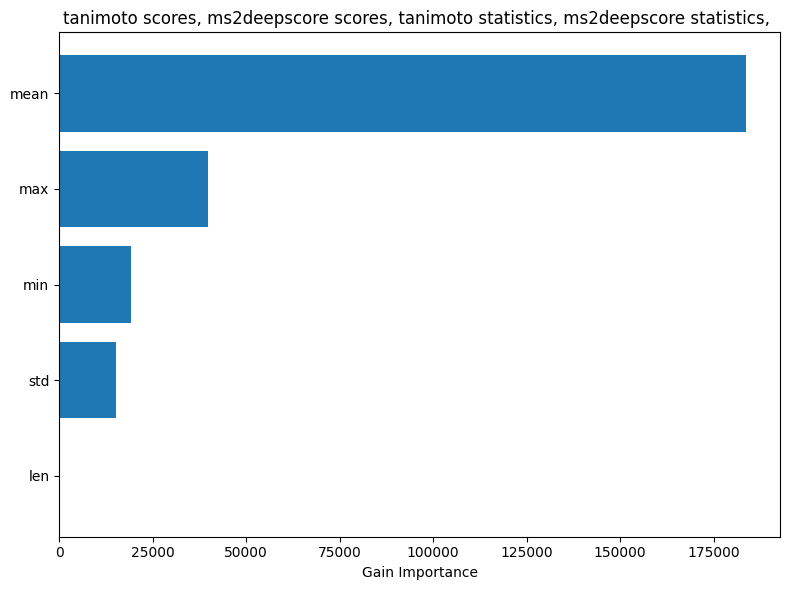

In [139]:
selected_feature_names = ["mean","std", "max", "min", "len"]

# Gain-based importance (best for ranking)
importance = regression_model.feature_importance(importance_type='gain')
# Sort descending
sorted_idx = np.argsort(importance)[::-1]
plt.figure(figsize=(8, 6))
plt.barh(
    np.array(selected_feature_names)[sorted_idx],
    importance[sorted_idx]
)
plt.gca().invert_yaxis()
plt.title(model_name)
plt.xlabel("Gain Importance")
plt.tight_layout()
plt.show()

In [144]:
predicted_inchikeys, scores = get_predictions_and_scores(all_val_ms2ds_features_per_query, regression_model, all_ms2deepscores_for_top_inchikeys_pos_pos)
prediction_fractions_1, average_tanimotos_1 = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, scores, np.linspace(min(scores)+ 0.1, max(scores) - 0.1, 30))


0it [00:00, ?it/s]

thresholds:   0%|          | 0/30 [00:00<?, ?it/s]

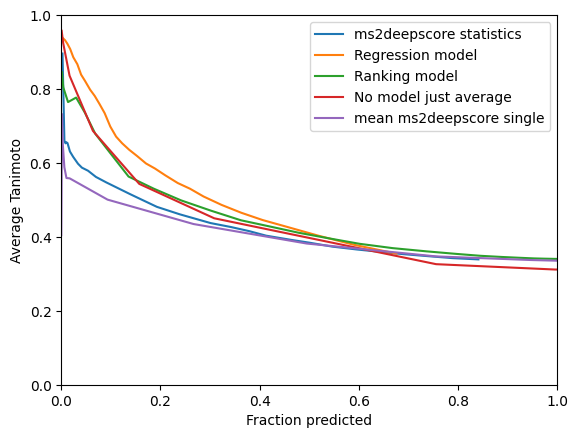

In [145]:
plt.plot(prediction_fractions_1, average_tanimotos_1, label="ms2deepscore statistics")
prediction_fraction, average_tanimotos = model_results_dict['regression tanimoto scores, ms2deepscore scores, tanimoto statistics, ms2deepscore statistics, ']
plt.plot(prediction_fraction, average_tanimotos, label = "Regression model")
prediction_fraction, average_tanimotos = model_results_dict['ranking tanimoto scores, ms2deepscore scores, tanimoto statistics, ms2deepscore statistics, ']
plt.plot(prediction_fraction, average_tanimotos, label = "Ranking model")
plt.plot(prediction_fractions_average_over_top_inchikeys_pos_pos, average_tanimotos_average_over_top_inchikeys_pos_pos, label = "No model just average")
plt.plot(prediction_fractions_mean_for_higest_ms2deepscore, average_tanimotos_mean_for_higest_ms2deepscore, label="mean ms2deepscore single")

 
plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

In [127]:
ms2ds_features_per_query = np.array(ms2ds_features_per_query)

In [130]:
ms2ds_features_per_query.shape

(3647300, 5)

# Test for reranking of top 1000


In [146]:
with open(os.path.join(pickled_intermediates_data_folder, "close_tanimoto_scores_top_1000_ms2deepscores.pickle"), "rb") as handle:
    top_k_tanimoto_scores_1000 = pickle.load(handle)

In [152]:
   
def predict_on_average_over_top_inchikeys_already_means(dict_with_ms2deepscores_for_top_inchikeys):
    highest_mean = 0
    best_inchikey = None
    for inchikey, inchikey_with_scores in dict_with_ms2deepscores_for_top_inchikeys.items():
        scores = list(inchikey_with_scores.values())
        mean = sum(scores)/10
        if mean > highest_mean:
            highest_mean = mean
            best_inchikey = inchikey
    return best_inchikey, highest_mean

In [153]:
predicted_inchikeys, predicted_scores = predict_best_inchikeys(top_k_tanimoto_scores_1000, predict_on_average_over_top_inchikeys_already_means)
prediction_fractions_average_over_top_inchikeys_top_1000, average_tanimotos_average_over_top_inchikeys_top_1000 = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

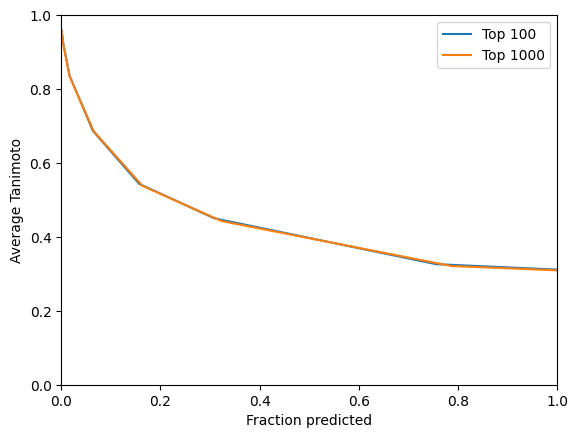

In [154]:
plt.plot(prediction_fractions_average_over_top_inchikeys_pos_pos, average_tanimotos_average_over_top_inchikeys_pos_pos, label = "Top 100")
plt.plot(prediction_fractions_average_over_top_inchikeys_top_1000, average_tanimotos_average_over_top_inchikeys_top_1000, label="Top 1000")

plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

# test with less than 100 top inchikeys

In [173]:
def predict_on_mean_top_k(all_ms2deepscores_for_top_inchikeys, k):
    predicted_inchikeys = []
    predicted_scores =[]
    
    for single_query in tqdm(all_ms2deepscores_for_top_inchikeys):
        max_score_per_inchikey = []
        inchikeys = list(single_query.keys())
        for inchikey in inchikeys:
            max_per_inchikey = single_query[inchikey].get_max_per_inchikey()
            if inchikey in max_per_inchikey.keys():
                max_score_per_inchikey.append(max_per_inchikey[inchikey])
            else:
                max_score_per_inchikey.append(max(list(max_per_inchikey.values())))
        idx = np.argsort(max_score_per_inchikey)[-k:][::-1]
    
        highest_mean = 0
        best_inchikey = None
        for index in idx:
            inchikey = inchikeys[index]
            scores = single_query[inchikey]
            mean = scores.get_mean()
            if mean > highest_mean:
                highest_mean = mean
                best_inchikey = inchikey
        predicted_inchikeys.append(best_inchikey)
        predicted_scores.append(highest_mean)
    return predicted_inchikeys, predicted_scores


In [174]:
predicted_inchikeys, predicted_scores = predict_on_mean_top_k(all_ms2deepscores_for_top_inchikeys_pos_pos, 1)
prediction_fractions_average_over_top_inchikeys_top_1, average_tanimotos_average_over_top_inchikeys_top_1 = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

In [175]:
predicted_inchikeys, predicted_scores = predict_on_mean_top_k(all_ms2deepscores_for_top_inchikeys_pos_pos, 5)
prediction_fractions_average_over_top_inchikeys_top_5, average_tanimotos_average_over_top_inchikeys_top_5 = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

In [176]:
predicted_inchikeys, predicted_scores = predict_on_mean_top_k(all_ms2deepscores_for_top_inchikeys_pos_pos, 20)
prediction_fractions_average_over_top_inchikeys_top_20, average_tanimotos_average_over_top_inchikeys_top_20 = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

In [177]:
predicted_inchikeys, predicted_scores = predict_on_mean_top_k(all_ms2deepscores_for_top_inchikeys_pos_pos, 50)
prediction_fractions_average_over_top_inchikeys_top_50, average_tanimotos_average_over_top_inchikeys_top_50 = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

In [180]:
predicted_inchikeys, predicted_scores = predict_on_mean_top_k(all_ms2deepscores_for_top_inchikeys_pos_pos, 100)
prediction_fractions_average_over_top_inchikeys_top_100, average_tanimotos_average_over_top_inchikeys_top_100 = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

  0%|          | 0/36473 [00:00<?, ?it/s]

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

In [169]:
prediction_fractions_average_over_top_inchikeys_top_10, average_tanimotos_average_over_top_inchikeys_top_10 = get_average_tanimoto_for_list_of_thresholds(val_pos, val_and_train_fingerprints_pos_pos, predicted_inchikeys, predicted_scores, [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])

thresholds:   0%|          | 0/9 [00:00<?, ?it/s]

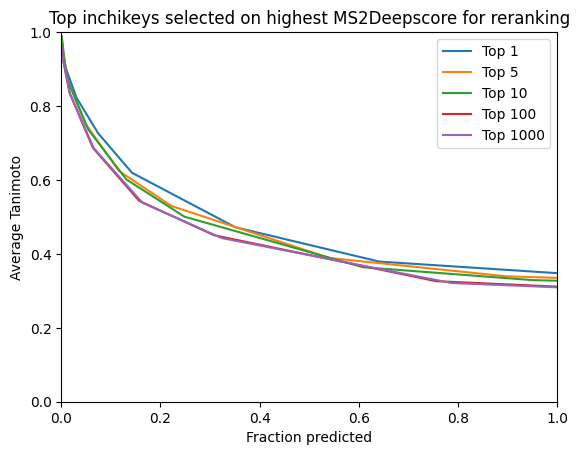

In [190]:

plt.plot(prediction_fractions_average_over_top_inchikeys_top_1, average_tanimotos_average_over_top_inchikeys_top_1, label="Top 1")
plt.plot(prediction_fractions_average_over_top_inchikeys_top_5, average_tanimotos_average_over_top_inchikeys_top_5, label="Top 5")
plt.plot(prediction_fractions_average_over_top_inchikeys_top_10, average_tanimotos_average_over_top_inchikeys_top_10, label="Top 10")
# plt.plot(prediction_fractions_average_over_top_inchikeys_top_20, average_tanimotos_average_over_top_inchikeys_top_20, label="Top 20")
# plt.plot(prediction_fractions_average_over_top_inchikeys_top_50, average_tanimotos_average_over_top_inchikeys_top_50, label="Top 50")
plt.plot(prediction_fractions_average_over_top_inchikeys_pos_pos, average_tanimotos_average_over_top_inchikeys_pos_pos, label = "Top 100")
plt.plot(prediction_fractions_average_over_top_inchikeys_top_1000, average_tanimotos_average_over_top_inchikeys_top_1000, label="Top 1000")
# plt.plot(prediction_fractions_average_over_top_inchikeys_top_100, average_tanimotos_average_over_top_inchikeys_top_100, label="Top 100 sanity check")
# plt.plot(prediction_fractions_highest_ms2deepscore_pos_pos, average_tanimotos_highest_ms2deepscore_pos_pos, label="Top 1 no reranking")
plt.title("Top inchikeys selected on highest MS2Deepscore for reranking")
plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

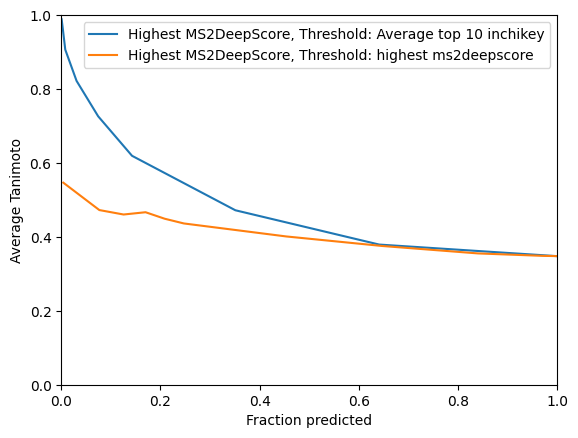

In [189]:

plt.plot(prediction_fractions_average_over_top_inchikeys_top_1, average_tanimotos_average_over_top_inchikeys_top_1, label="Highest MS2DeepScore, Threshold: Average top 10 inchikey")
plt.plot(prediction_fractions_highest_ms2deepscore_pos_pos, average_tanimotos_highest_ms2deepscore_pos_pos, label="Highest MS2DeepScore, Threshold: highest ms2deepscore")

plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

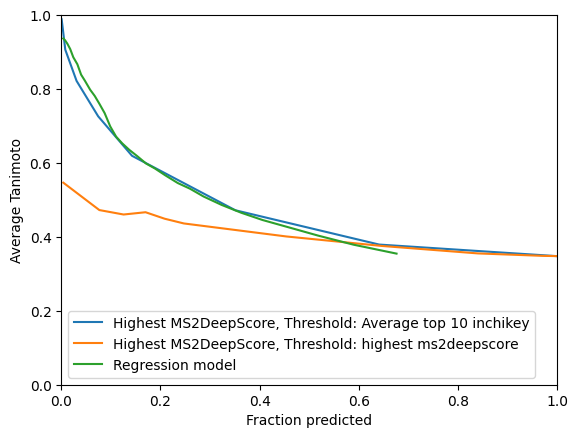

In [194]:

plt.plot(prediction_fractions_average_over_top_inchikeys_top_1, average_tanimotos_average_over_top_inchikeys_top_1, label="Highest MS2DeepScore, Threshold: Average top 10 inchikey")
plt.plot(prediction_fractions_highest_ms2deepscore_pos_pos, average_tanimotos_highest_ms2deepscore_pos_pos, label="Highest MS2DeepScore, Threshold: highest ms2deepscore")
prediction_fraction, average_tanimotos = model_results_dict['regression tanimoto scores, ms2deepscore scores, tanimoto statistics, ms2deepscore statistics, ']
plt.plot(prediction_fraction, average_tanimotos, label = "Regression model")
plt.xlabel("Fraction predicted")
plt.ylabel("Average Tanimoto")
plt.legend()
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

# Conclusion
So this showed that the most promising method was going for just the highest MS2DeepScore, but focus on predicting the reliability for these predictions. This is what we do in the cleaned notebook.

# Below is not reproducible
This should be run after the other cleaned notebook, to get examples of cases wher MS2DeepScore is high, but mod cos is low. 

In [719]:
from matchms import Spectrum
from matchms.similarity import ModifiedCosine
import numpy as np
similarity = ModifiedCosine(tolerance=0.2)

array(1.)

0.9375421035244955
1.0


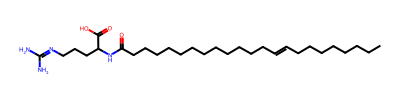

correct molecule: 


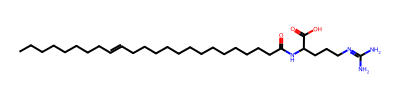

0.1755122261320506
45.0
35.0


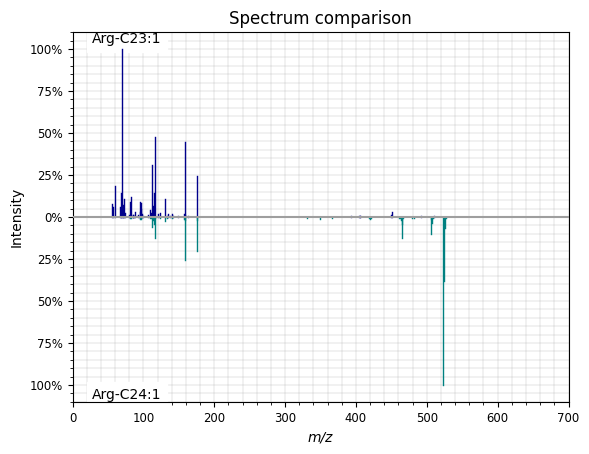

0.9361012758860069
1.0


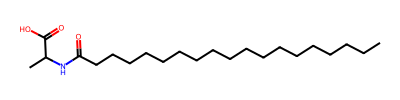

correct molecule: 


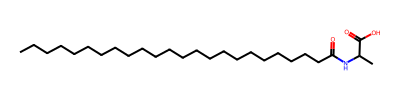

0.4546702879113751
45.0
33.0


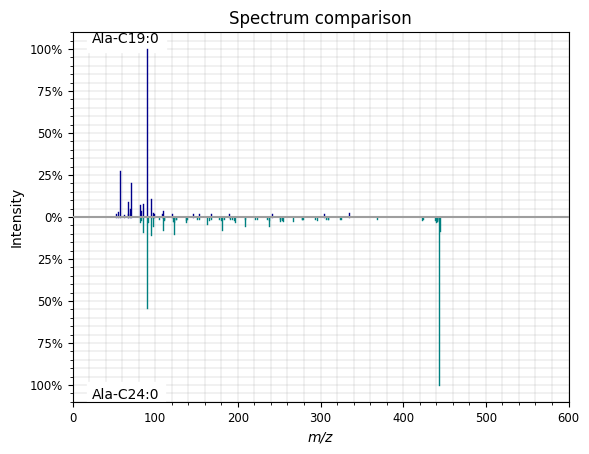

0.9322115989267339
1.0


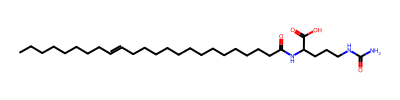

correct molecule: 


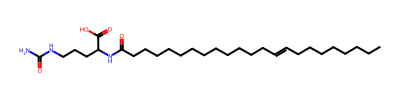

0.4422802277402988
45.0
35.0


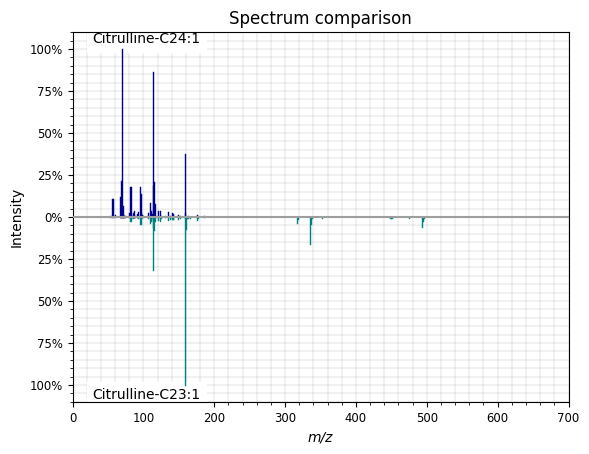

0.930407120217078
1.0


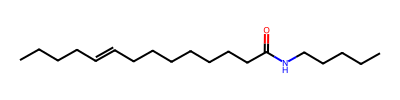

correct molecule: 


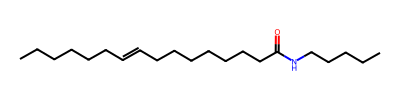

0.27169997306973426
45.0
30.0


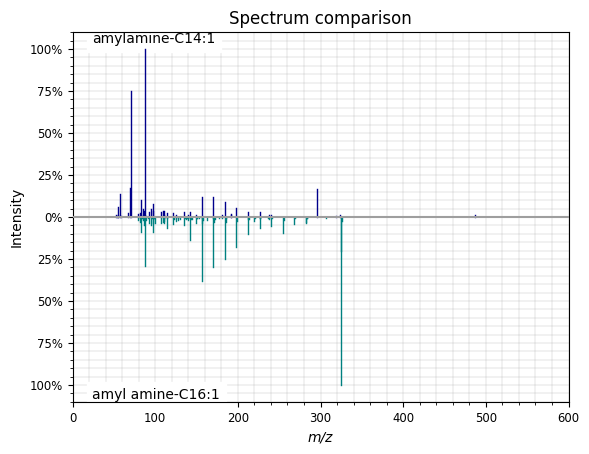

0.9289505153786127
1.0


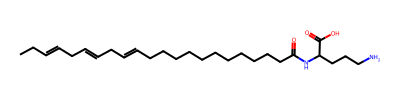

correct molecule: 


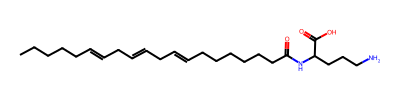

0.22314463310751284
45.0
33.0


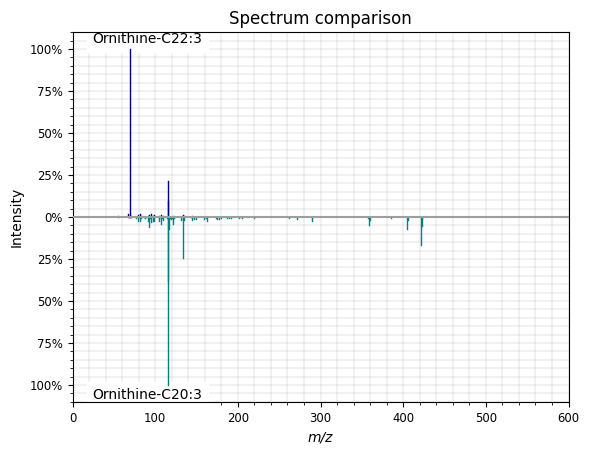

0.9270447729483859
0.9708738


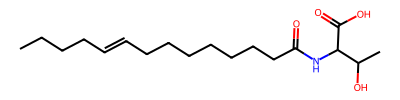

correct molecule: 


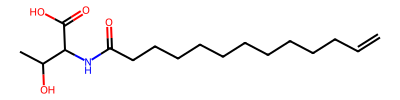

0.542677734214159
45.0
30.0


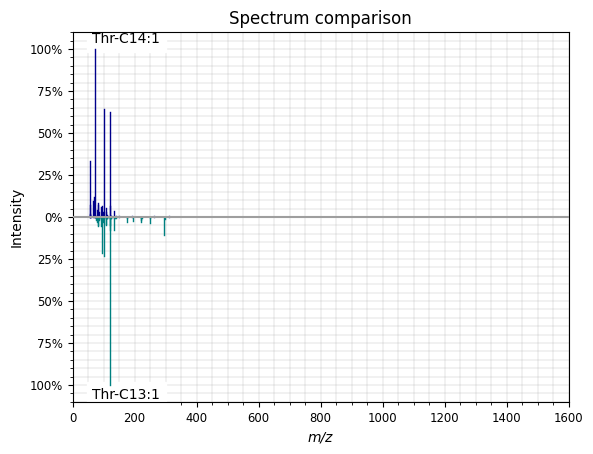

0.9235437291300022
1.0


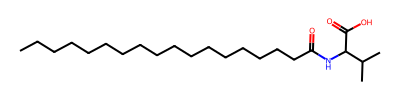

correct molecule: 


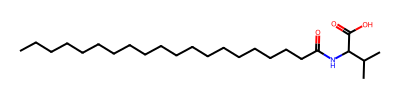

0.11970050274614707
45.0
32.0


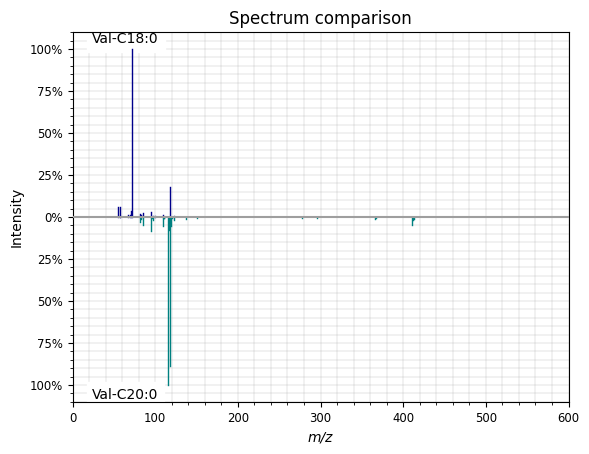

0.9225604794077873
1.0


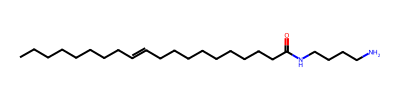

correct molecule: 


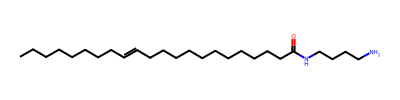

0.08808866368361683
45.0
32.0


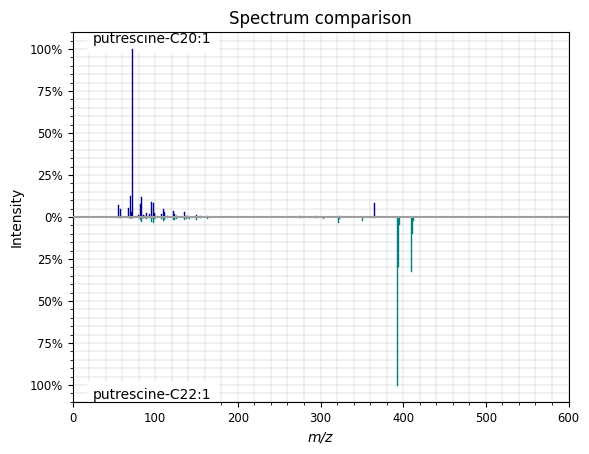

0.9215788977711578
1.0


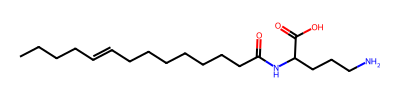

correct molecule: 


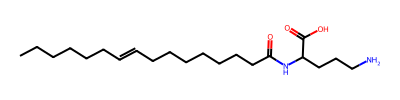

0.24408761516333474
45.0
31.0


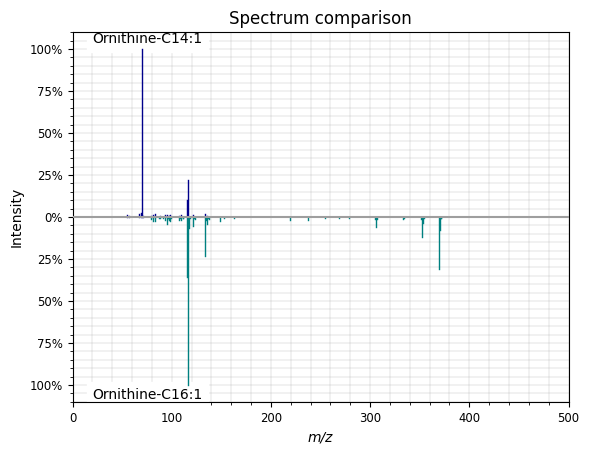

0.9208676765364343
1.0


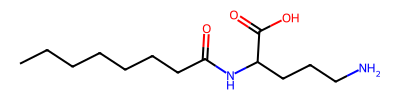

correct molecule: 


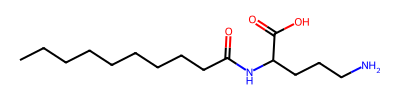

0.2716851203629264
45.0
29.0


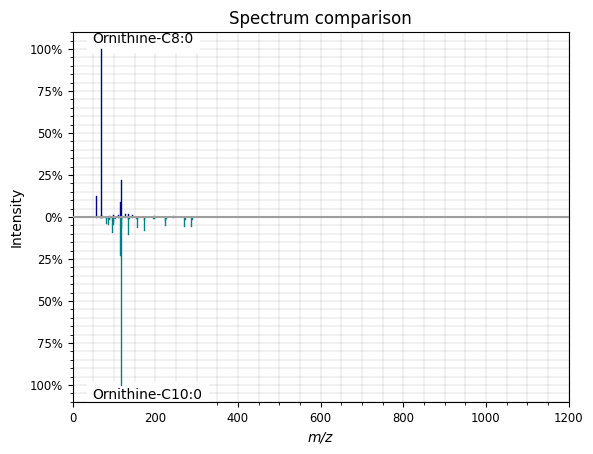

0.9205774775932374
1.0


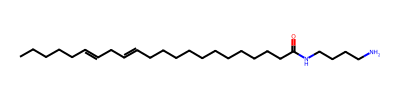

correct molecule: 


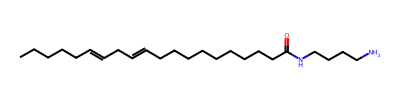

0.07058460536368574
45.0
31.0


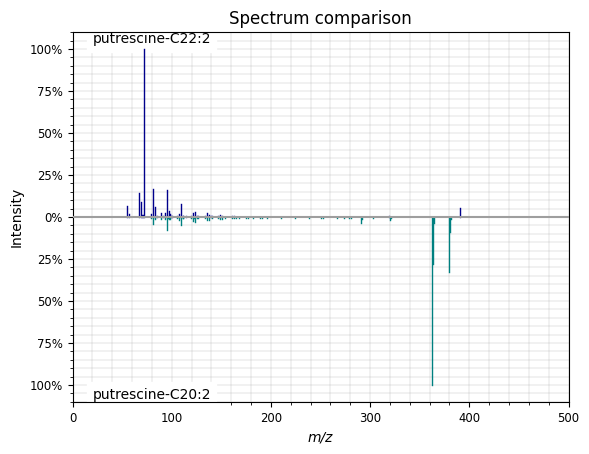

0.9150546772452577
1.0


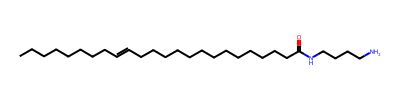

correct molecule: 


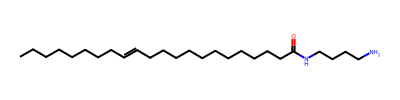

0.07203742057109745
45.0
32.0


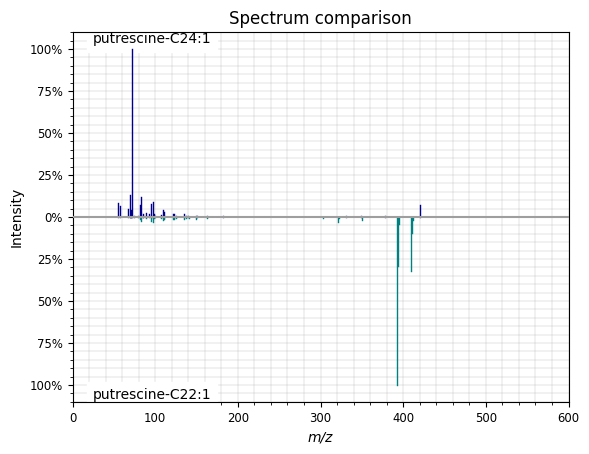

0.9137588292660064
1.0


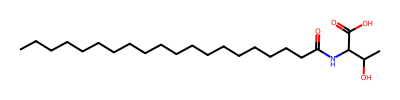

correct molecule: 


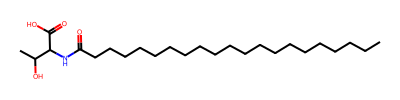

0.55066423348364
45.0
33.0


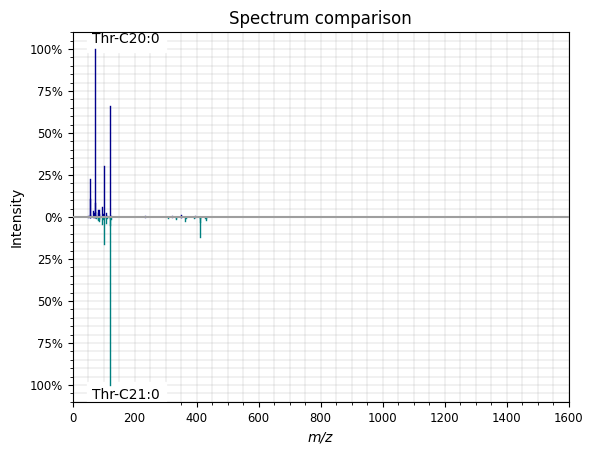

0.9095597143396202
0.89544237


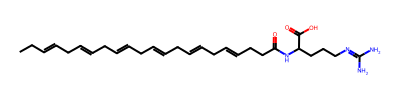

correct molecule: 


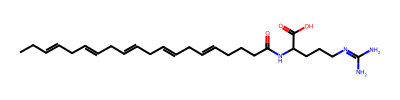

0.20225711068584964
45.0
33.0


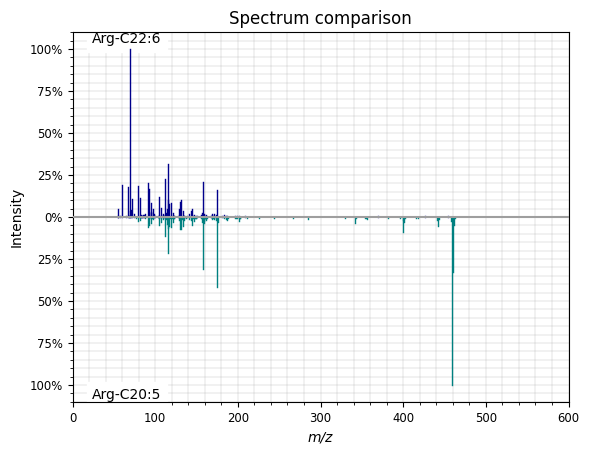

In [728]:
from rdkit import Chem
from rdkit.Chem import Draw
similarity = ModifiedCosine(tolerance=0.2)
inchikeys = set()
for index in top_100_indices:
    inchikey = val_pos.spectra[index].get("inchikey")[:14]
    if inchikey not in inchikeys:
        correct_inchikey = list(close_tanimoto_scores_1_ms2deepscore_100_inchikeys[index].keys())[0]
        mod_cos = similarity.pair(val_pos.spectra[index], train_pos.spectra_per_inchikey(correct_inchikey)[0])["score"]
        if mod_cos < 0.6:
            print(average_mean_top_8_thresholds[index])
            print(best_possible_threshold[index])
            inchikeys.add(inchikey)
            smiles = val_pos.spectra[index].get("smiles")
            mol = Chem.MolFromSmiles(smiles)
            img = Draw.MolToImage(mol, size=(400, 100))
            img.show()
            print("correct molecule: ")
            correct_smiles = train_pos.spectra_per_inchikey(correct_inchikey)[0].get("smiles")
            mol = Chem.MolFromSmiles(correct_smiles)
            img = Draw.MolToImage(mol, size=(400, 100))
            img.show()
        
            print(mod_cos)
            print(val_pos.spectra[index].get("collision_energy"))
            print(train_pos.spectra_per_inchikey(correct_inchikey)[0].get("collision_energy"))
            plot_spectra_mirror(val_pos.spectra[index], train_pos.spectra_per_inchikey(correct_inchikey)[0])
            plt.show()